In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Atin_Customer_Churn_Analysis.xlsx to Atin_Customer_Churn_Analysis.xlsx


In [2]:
df = pd.read_excel("Atin_Customer_Churn_Analysis.xlsx")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [6]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [7]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [8]:
df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


In [9]:
df.groupby(
    pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 48, 72],
        labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
    )
)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

/tmp/ipykernel_1044/2771072386.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,Churn
tenure,
0-12 months,47.678161
13-24 months,28.710938
25-48 months,20.388959
49-72 months,9.513176


In [10]:
df.groupby(['Contract', pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)])['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

/tmp/ipykernel_1044/2959773983.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Contract', pd.cut(


Contract        tenure      
Month-to-month  0-12 months     51.354062
                13-24 months    37.720488
                25-48 months    32.917706
                49-72 months    26.023392
One year        0-12 months     10.569106
                13-24 months     8.121827
                25-48 months    10.617761
                49-72 months    12.933754
Two year        0-12 months      0.000000
                13-24 months     0.000000
                25-48 months     2.189781
                49-72 months     3.325416
Name: Churn, dtype: float64

In [11]:
df.groupby(
    pd.qcut(df['MonthlyCharges'], 4),
    observed=True
)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

,Churn
MonthlyCharges,
"(18.249, 35.5]",11.237230
"(35.5, 70.35]",24.575311
"(70.35, 89.85]",37.507114
"(89.85, 118.75]",32.878271


In [12]:
df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

,Churn
InternetService,
Fiber optic,41.892765
DSL,18.959108
No,7.404980


In [13]:
df.groupby('InternetService')['MonthlyCharges'].mean()

,MonthlyCharges
InternetService,
DSL,58.102169
Fiber optic,91.500129
No,21.079194


In [14]:
df.groupby('InternetService')['Contract'].value_counts(normalize=True)

InternetService  Contract      
DSL              Month-to-month    0.505163
                 Two year          0.259397
                 One year          0.235440
Fiber optic      Month-to-month    0.687339
                 One year          0.174096
                 Two year          0.138566
No               Two year          0.418087
                 Month-to-month    0.343381
                 One year          0.238532
Name: proportion, dtype: float64

In [15]:
df.groupby('TechSupport')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

,Churn
TechSupport,
No,41.635474
Yes,15.166341
No internet service,7.404980


In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [18]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [19]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [20]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [21]:
df.dtypes['TotalCharges']

dtype('float64')

In [22]:
# Remove customer ID because it has no predictive value
df_model = df.drop(columns=['customerID']).copy()

# Convert categorical variables into numerical dummy variables
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,0,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,0,0,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,0,0,True,False,False,True,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,0,3,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,0,0,False,False,False,True,...,False,False,False,False,False,True,False,True,False,True


In [23]:
X = df_model.drop(columns=['Churn_Yes'])
y = df_model['Churn_Yes']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 32)
Target: (7043,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

Training customers: 5634
Testing customers: 1409


In [26]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [27]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Predicted classes:", y_pred[:10])
print("Churn probabilities:", y_prob[:10])

Predicted classes: [False  True False False False False False False False False]
Churn probabilities: [1.54008503e-04 6.51375081e-01 6.91577265e-03 2.84535091e-01
 1.80782574e-04 3.18675589e-01 2.53097201e-01 3.36191358e-01
 4.54666144e-04 3.34795118e-01]


In [28]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.89      0.92      0.91      1035
        True       0.76      0.68      0.72       374

    accuracy                           0.86      1409
   macro avg       0.82      0.80      0.81      1409
weighted avg       0.86      0.86      0.86      1409

ROC-AUC: 0.9276059831047044


In [29]:
risk_df = X_test.copy()

risk_df['Actual_Churn'] = y_test.values
risk_df['Churn_Probability'] = y_prob

risk_df['Risk_Level'] = pd.cut(
    risk_df['Churn_Probability'],
    bins=[0, 0.40, 0.70, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

risk_df['Risk_Level'].value_counts()

,count
Risk_Level,
Low Risk,999
Medium Risk,210
High Risk,200


In [30]:
risk_df.groupby('Risk_Level', observed=True)['Actual_Churn'].mean() * 100

,Actual_Churn
Risk_Level,
Low Risk,8.508509
Medium Risk,54.761905
High Risk,87.000000


In [31]:
high_risk = risk_df[risk_df['Risk_Level'] == 'High Risk']

print("High-risk customers:", len(high_risk))
print("\nAverage tenure:")
print(high_risk['tenure'].mean())

print("\nAverage monthly charges:")
print(high_risk['MonthlyCharges'].mean())

print("\nAverage total charges:")
print(high_risk['TotalCharges'].mean())

High-risk customers: 200

Average tenure:
17.66

Average monthly charges:
84.88600000000001

Average total charges:
1637.1295


In [32]:
print("\nHigh-risk contract mix:")
print(
    high_risk[
        [col for col in high_risk.columns if 'Contract_' in col]
    ].mean()
)


High-risk contract mix:
Contract_One year    0.075
Contract_Two year    0.020
dtype: float64


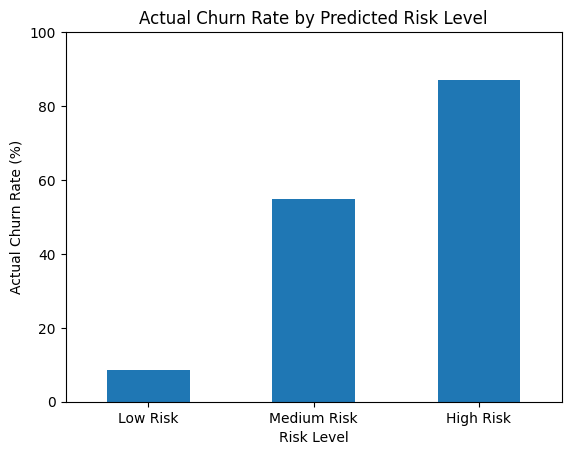

In [33]:
import matplotlib.pyplot as plt

risk_churn = (
    risk_df.groupby('Risk_Level', observed=True)['Actual_Churn']
    .mean() * 100
)

risk_churn.plot(kind='bar')

plt.title('Actual Churn Rate by Predicted Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Actual Churn Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()